In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [79]:
df = pd.read_csv(r"C:\Users\Vijay_k943wj6\Desktop\datascience\python\Notes\Data Analyse\Data\population_data.csv")

In [49]:
df

,id,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,India,1463865525,0.89%,12929734,492,2973190,"−495,753",1.94,28.8,37.1%,17.78%
1,2,China,1416096094,−0.23%,"−3,225,184",151,9388211,"−268,126",1.02,40.1,67.5%,17.20%
2,3,United States,347275807,0.54%,1849236,38,9147420,1230663,1.62,38.5,82.8%,4.22%
3,4,Indonesia,285721236,0.79%,2233305,158,1811570,"−39,509",2.10,30.4,59.6%,3.47%
4,5,Pakistan,255219554,1.57%,3950390,331,770880,"−1,235,336",3.50,20.6,34.4%,3.10%
...,...,...,...,...,...,...,...,...,...,...,...,...
228,229,Montserrat,4359,−0.68%,−30,44,100,−9,1.45,41.6,11.5%,0.000053%
229,230,Falkland Islands,3469,−0.03%,−1,0,12170,−17,1.70,42.8,68%,0.000042%
230,231,Tokelau,2608,4.07%,102,261,10,53,2.57,27.3,NaN,0.000032%
231,232,Niue,1821,0.11%,2,7,260,3,2.46,35.7,44.5%,0.000022%


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       233 non-null    int64  
 1   Country (or dependency)  233 non-null    object 
 2   Population 2025          233 non-null    int64  
 3   Yearly Change            233 non-null    object 
 4   Net Change               233 non-null    object 
 5   Density (P/Km²)          233 non-null    int64  
 6   Land Area (Km²)          233 non-null    int64  
 7   Migrants (net)           233 non-null    object 
 8   Fert. Rate               233 non-null    float64
 9   Median Age               233 non-null    float64
 10  Urban Pop %              210 non-null    object 
 11  World Share              233 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 22.0+ KB


#### Here We have 233 Rows and 12 Columns.
#### Country (or dependency) - The Country Name. 
#### Population 2025 = The Total Population Rate of that Respective Country 
#### Yearly Change - How Much Change Occurs in Yearly Basis.
#### Net Change	Density (P/Km²) - The Density Rate of Country.
#### Land Area (Km²)	Migrants (net) - The Land Area in (Km²). 
#### Fert. Rate - The Fertiliy Rate of that Country
#### Median Age - The Average Age of that Contry
#### Urban Pop % - The Urban Population (in Percentage) of that Country
#### World Share - World Share of Population of that Country
#### There's Nun Value Here in Urban Pop%.

In [51]:
df['Urban Pop %'] = df['Urban Pop %'].fillna(df['Urban Pop %'].mode()[0])

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       233 non-null    int64  
 1   Country (or dependency)  233 non-null    object 
 2   Population 2025          233 non-null    int64  
 3   Yearly Change            233 non-null    object 
 4   Net Change               233 non-null    object 
 5   Density (P/Km²)          233 non-null    int64  
 6   Land Area (Km²)          233 non-null    int64  
 7   Migrants (net)           233 non-null    object 
 8   Fert. Rate               233 non-null    float64
 9   Median Age               233 non-null    float64
 10  Urban Pop %              233 non-null    object 
 11  World Share              233 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 22.0+ KB


#### Now No Nun Value Here in Urban Pop%.

In [10]:
df.describe()

,id,Population 2025,Density (P/Km²),Land Area (Km²),Fert. Rate,Median Age
count,233.000000,2.330000e+02,233.000000,2.330000e+02,233.000000,233.000000
mean,117.000000,3.532080e+07,487.673820,5.583427e+05,2.306094,31.896996
std,67.405489,1.391905e+08,2412.937646,1.694270e+06,1.134316,9.860936
min,1.000000,5.010000e+02,0.000000,0.000000e+00,0.690000,14.500000
25%,59.000000,4.663300e+05,38.000000,2.830000e+03,1.470000,22.900000
50%,117.000000,5.731206e+06,98.000000,8.220000e+04,1.940000,32.800000
75%,175.000000,2.407458e+07,256.000000,4.103400e+05,2.950000,39.800000
max,233.000000,1.463866e+09,25732.000000,1.637687e+07,5.940000,57.400000


In [11]:
df.describe(include = 'object')

,Country (or dependency),Yearly Change,Net Change,Migrants (net),Urban Pop %,World Share
count,233,233,233,233,233,233
unique,233,177,231,233,191,165
top,India,2.43%,156,"−495,753",27.7%,0.13%
freq,1,4,2,1,25,8


In [33]:
df['Population_Rank'] = df['Population 2025'].rank(method='dense', ascending=False).astype(int)

In [34]:
top_10 = df.groupby(['Country (or dependency)','Population 2025'])['Population_Rank']

In [35]:
top_10 = df.sort_values(by='Population 2025', ascending=False).head(10)
top_10

,id,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share,Population_Rank
0,1,India,1463865525,0.89%,12929734,492,2973190,"−495,753",1.94,28.8,37.1%,17.78%,1
1,2,China,1416096094,−0.23%,"−3,225,184",151,9388211,"−268,126",1.02,40.1,67.5%,17.20%,2
2,3,United States,347275807,0.54%,1849236,38,9147420,1230663,1.62,38.5,82.8%,4.22%,3
3,4,Indonesia,285721236,0.79%,2233305,158,1811570,"−39,509",2.10,30.4,59.6%,3.47%,4
4,5,Pakistan,255219554,1.57%,3950390,331,770880,"−1,235,336",3.50,20.6,34.4%,3.10%,5
5,6,Nigeria,237527782,2.08%,4848304,261,910770,"−15,258",4.30,18.1,54.9%,2.89%,6
6,7,Brazil,212812405,0.38%,813832,25,8358140,"−217,283",1.60,34.8,91.4%,2.59%,7
7,8,Bangladesh,175686899,1.22%,2124535,1350,130170,"−402,100",2.11,26.0,42.6%,2.13%,8
8,9,Russia,143997393,−0.57%,"−823,030",9,16376870,"−251,822",1.47,40.3,75%,1.75%,9
9,10,Ethiopia,135472051,2.58%,3412284,135,1000000,24054,3.81,19.1,22.5%,1.65%,10


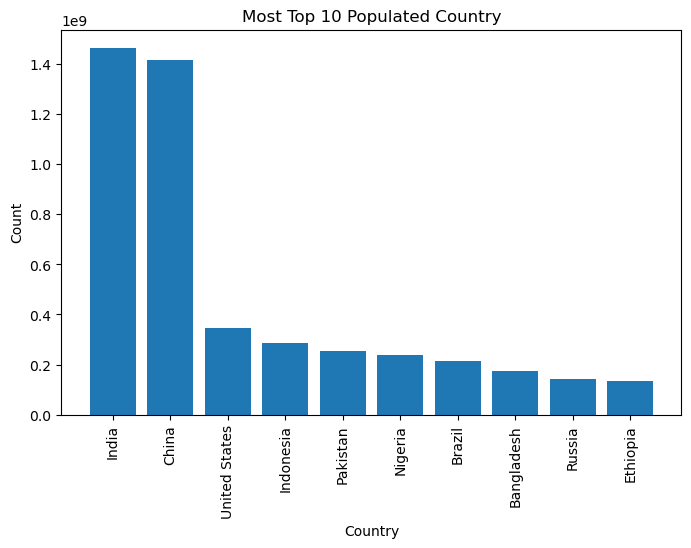

In [56]:
plt.figure(figsize = (8,5))
plt.bar(
   top_10['Country (or dependency)'],
    top_10['Population 2025']
)
plt.xticks(rotation = 90)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Most Top 10 Populated Country')
plt.show()

* #### This Line Graph is Represent the Top 10 Most Population Counts of World's Country.
* #### India and China are Most Populated Country.
* #### Third Country is USA, But USA have Huge Population Difference Between China and India.
* #### There's Gradually decreasing Bar after USA.
* #### But After India and China There's a Huge Crash to USA.

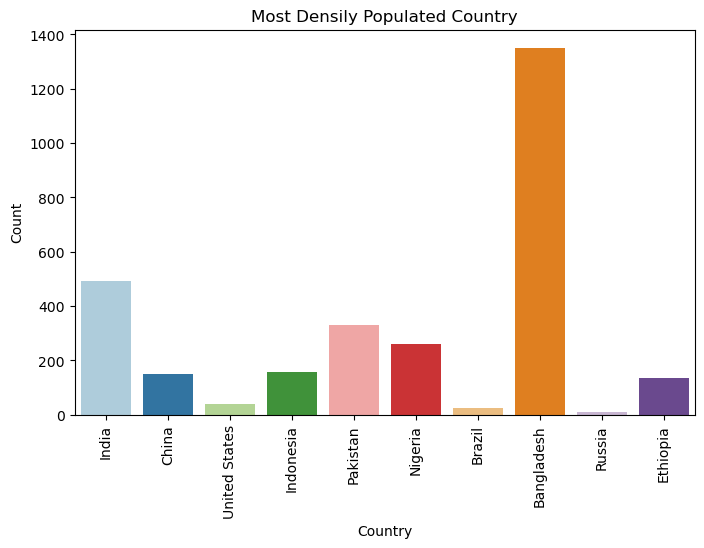

In [50]:
plt.figure(figsize = (8,5))
sns.barplot(
   data = top_10,
   x = 'Country (or dependency)',
   y = 'Density (P/Km²)',
   palette = 'Paired'
)
plt.xticks(rotation = 90)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Most Densily Populated Country')
plt.show()

* #### This Graph is Representing Most Densily Country in Most Top 10 Populated Country
* #### Bangladesh is the Most Densily Populated Country in the World.
* #### More than China and India (Populated Country).
* #### Bangladesh is Belongs to 92 Largest Country.
* #### Considering Size of that Country and Population the incrase of Density is Normal.
* #### Second Most Densily Populated Country is India.
* #### Third Position Holding China.
* #### Most Least is Russia (World Largest Country by Size).

In [66]:
df['Migrants (net)'] = pd.to_numeric(df['Migrants (net)'], errors='coerce')

In [67]:
migrants = df.sort_values(by='Migrants (net)', ascending=False)

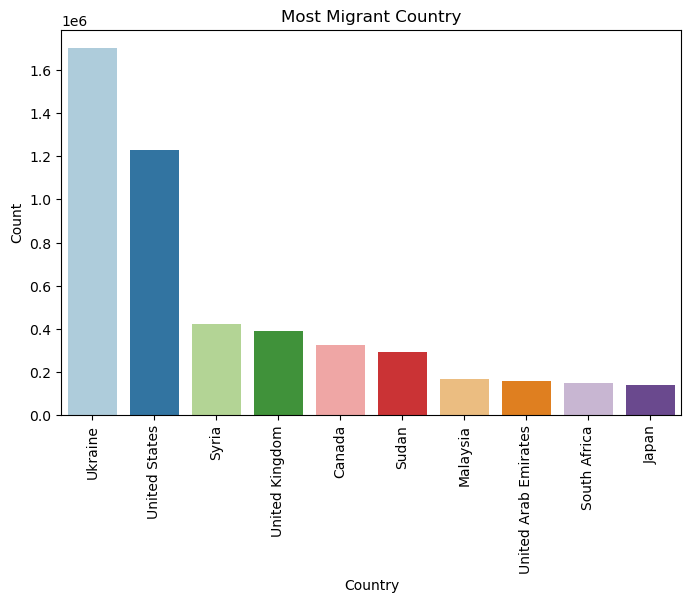

In [84]:
plt.figure(figsize = (8,5))
sns.barplot(
   data = top_10_mig,
   x = 'Country (or dependency)',
   y = 'Migrants (net)',
   palette = 'Paired'
)
plt.xticks(rotation = 90)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Most Migrant Country')
plt.show()

* #### This is the Visualization of Top 10 Migrant Country in the World.
* #### Ukarine is the Most Migrant Counrt According to this Data.
* #### USA Holds the Second Posiiton.
* #### Syria and U.K are the 3rd and 4th Positions.
* #### Japan is the Least of Top 10 Migrant Country.

In [37]:
df = df[df['Count3ry (or dependency)'] != 'Holy See'] 
# Dropping this Row because Holy see is not a Country it's the central government of the Catholic Church, 
# headed by the Pope, and is a sovereign entity in international law

In [42]:
high_med = df[['Median Age', 'Country (or dependency)']].sort_values(by = 'Median Age',ascending = False).reset_index().head(25)

* #### Median age that divides its population into two equal halves: one half is younger than this age, and the other half is older

In [43]:
high_med

,index,Median Age,Country (or dependency)
0,215,53.6,Monaco
1,227,50.9,Saint Helena
2,11,49.8,Japan
3,179,49.7,Martinique
4,217,48.6,San Marino
5,24,48.2,Italy
6,105,47.4,Hong Kong
7,226,47.2,Saint Pierre & Miquelon
8,178,47.2,Guadeloupe
9,92,46.9,Portugal


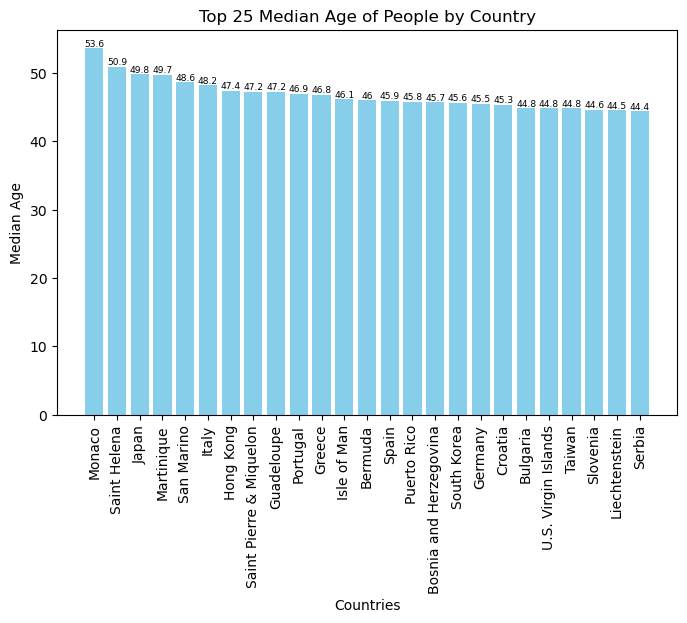

In [72]:
plt.figure(figsize = (8,5))
fig = plt.bar(
    high_med['Country (or dependency)'],
    high_med['Median Age'],
    color = 'skyblue'
)
plt.bar_label(fig,fontsize = 6.5)
plt.xticks(rotation = 90)
plt.xlabel('Countries')
plt.ylabel('Median Age')
plt.title('Top 25 Median Age of People by Country')
plt.show()

* #### This Visualization is Representing the Most Median Age of People by Country.
* #### Monaco is the Rating as the Most Median Age People (According to this Data) More than 50.
* #### Then Saint helena is the Second Most Country where People Median Age is Around 50.

In [39]:
low_med = df[['Median Age', 'Country (or dependency)']].sort_values(by = 'Median Age',ascending = False).reset_index().tail(25)
low_med

,index,Median Age,Country (or dependency)
207,29,18.5,Sudan
208,36,18.4,Yemen
209,74,18.3,Guinea
210,49,18.3,Côte d'Ivoire
211,61,18.1,Malawi
212,5,18.1,Nigeria
213,73,18.1,Zimbabwe
214,75,18.0,Benin
215,50,18.0,Cameroon
216,62,17.9,Zambia


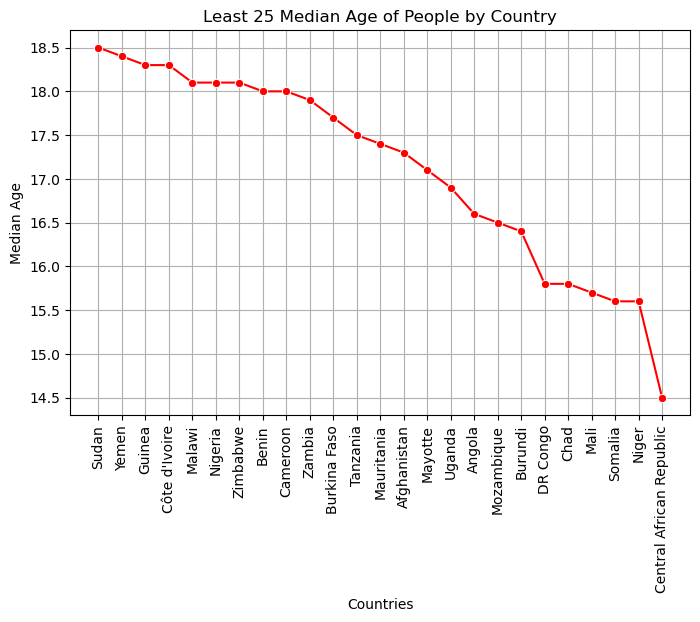

In [73]:
plt.figure(figsize = (8,5))
sns.lineplot(
    data =  low_med,
    x = 'Country (or dependency)',
    y = 'Median Age',
    color = 'Red',
    marker = 'o'
)
plt.xticks(rotation = 90)
plt.xlabel('Countries')
plt.ylabel('Median Age')
plt.grid()
plt.title('Least 25 Median Age of People by Country')
plt.show()

* #### This Visualization is Representing the Lowest Average Age of People by Country.
* #### Central African Republic Rating as the Most Lowest Average Age People (According to this Data) around 14.5.
* #### Sudan High Median Age People in the Lowest 18.5.
* #### These Median Age are Really Shocking because of the Avg.Age.

In [28]:
fert_25 = df[['Country (or dependency)','Fert. Rate']].sort_values(by = 'Fert. Rate',ascending = False).reset_index().head(50)

In [29]:
fert_25

,index,Country (or dependency),Fert. Rate
0,63,Chad,5.94
1,66,Somalia,5.91
2,14,DR Congo,5.90
3,120,Central African Republic,5.81
4,53,Niger,5.79
5,57,Mali,5.42
6,38,Angola,4.95
7,77,Burundi,4.67
8,35,Afghanistan,4.66
9,44,Mozambique,4.62


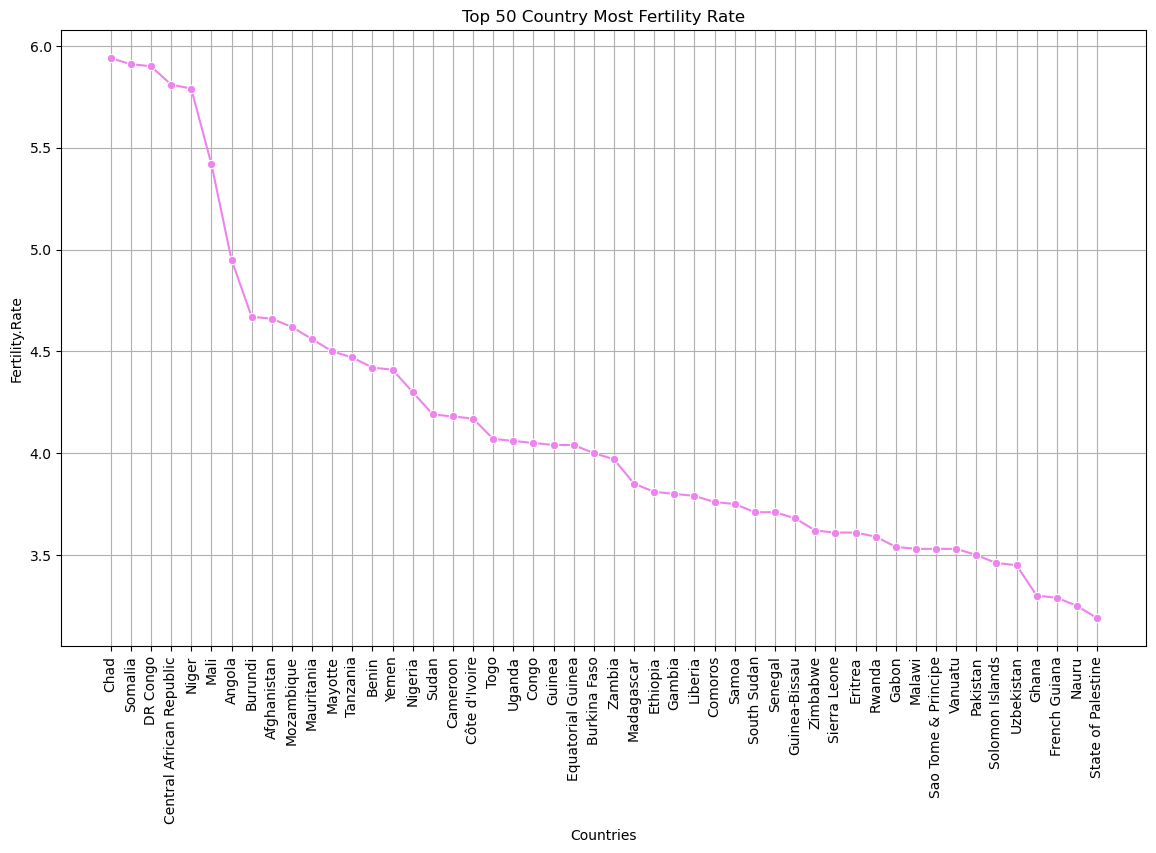

In [45]:
plt.figure(figsize = (14,8))
sns.lineplot(
    data =  fert_25,
    x = 'Country (or dependency)',
    y = 'Fert. Rate',
    color = 'Violet',
    marker = 'o'
)
plt.xticks(rotation = 90)
plt.xlabel('Countries')
plt.ylabel('Fertility.Rate')
plt.grid()
plt.title('Top 50 Country Most Fertility Rate')
plt.show()

* #### These Visualization is Used to Most Fert.Rate Countries According to This Data.
* #### Chad is the No.1 Fertility Rate Country in the World.
* #### Somalia is Second.
* #### First Five Countries (Chad, Somalia, DR.Congo, Central African Republic, Niger) then we can see a small downfall in the Graph.
* #### That means these are the 5 Countries Where Fert.Rate is Really High.
* #### After onwards the Graph is Falling downwards Fastly.

In [187]:
low_fert = df[['Country (or dependency)','Fert. Rate']].sort_values(by = 'Fert. Rate',ascending = False).reset_index().tail(50)
low_fert

,index,Country (or dependency),Fert. Rate
182,208,Turks and Caicos,1.44
183,165,Bhutan,1.44
184,70,Netherlands,1.44
185,100,Switzerland,1.44
186,90,Sweden,1.44
187,210,Sint Maarten,1.43
188,118,Norway,1.42
189,204,Bermuda,1.41
190,167,Luxembourg,1.40
191,224,Wallis & Futuna,1.40


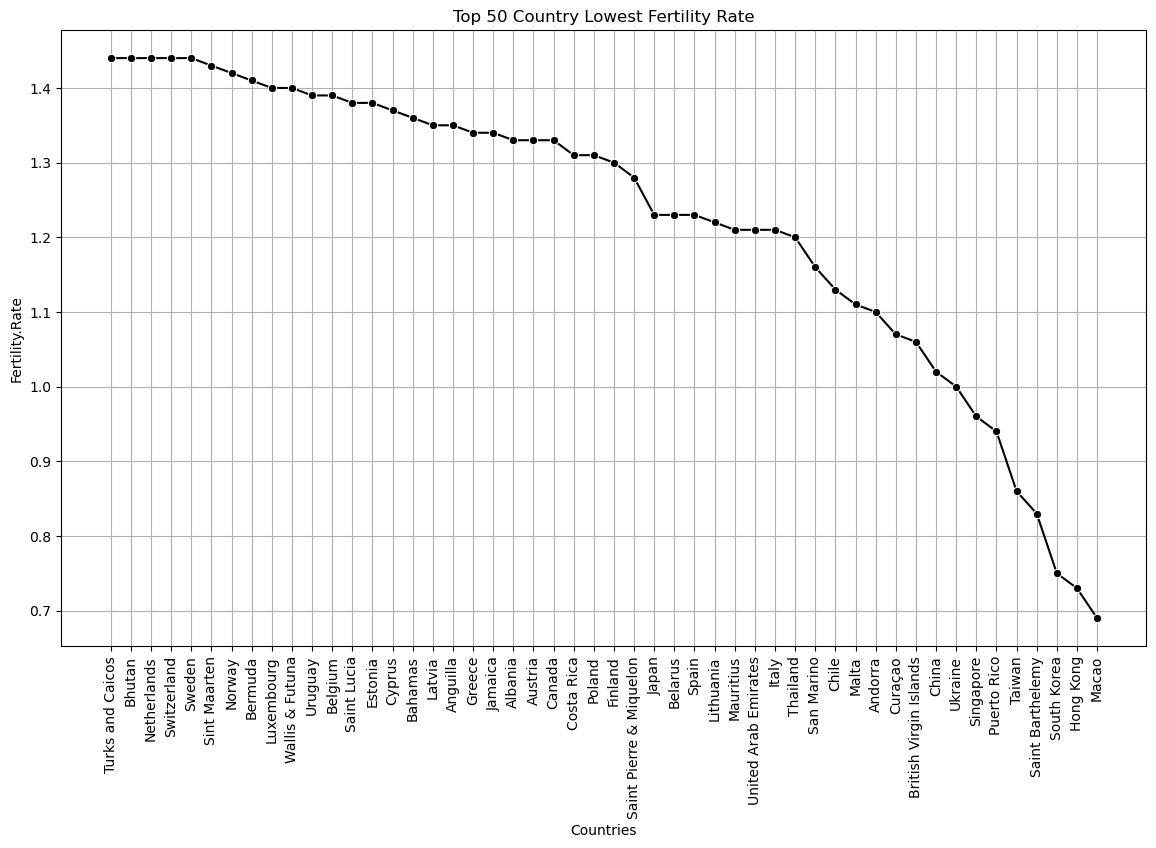

In [190]:
plt.figure(figsize = (14,8))
sns.lineplot(
    data =  low_fert,
    x = 'Country (or dependency)',
    y = 'Fert. Rate',
    color = 'black',
    marker = 'o'
)
plt.xticks(rotation = 90)
plt.xlabel('Countries')
plt.ylabel('Fertility.Rate')
plt.grid()
plt.title('Top 50 Country Lowest Fertility Rate')
plt.show()

* #### These Visualization is Used to Lowest Fert.Rate Countries According to This Data.
* #### Macao is the Lowest Fertility Rate Country in the World.
* #### Hong Kong is Second.
* #### In this List We can See Lot of Developed Countries Like Japan, South Korea, Netherlands, Norway, Canada etc. 
* #### On this Graph We can see Lot Of European Couttries Like Austria, Latvia, Belgium, Sweden etc.

In [6]:
urban = df[['Country (or dependency)','Urban Pop %']].sort_values(by = 'Urban Pop %',ascending = False).reset_index().head(50)
urban

,index,Country (or dependency),Urban Pop %
0,210,Sint Maarten,99.8%
1,190,Guam,98.8%
2,82,Belgium,98.8%
3,166,Macao,97.1%
4,170,Western Sahara,97%
5,136,Qatar,96.6%
6,34,Argentina,96%
7,182,French Guiana,94.5%
8,222,Nauru,94.2%
9,11,Japan,93.1%


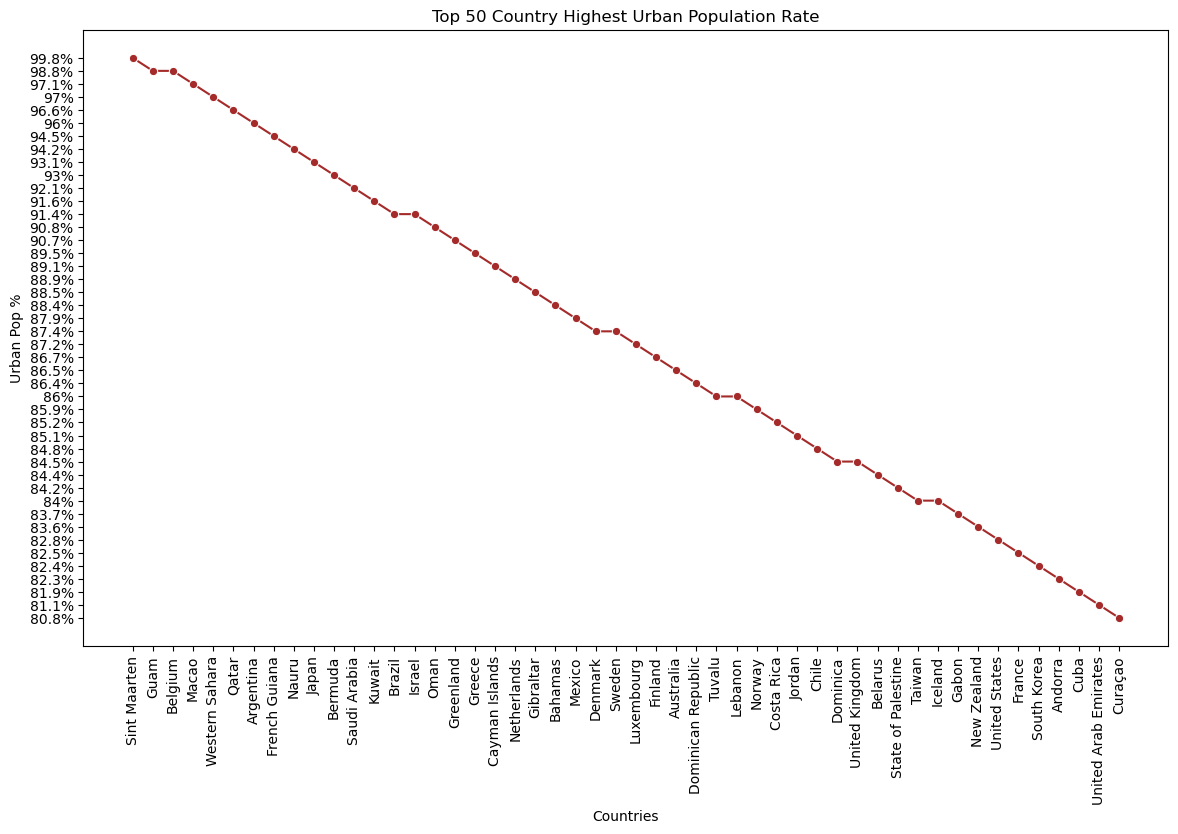

In [26]:
plt.figure(figsize = (14,8))
sns.lineplot(
    data =  urban,
    x = 'Country (or dependency)',
    y = 'Urban Pop %',
    color = 'brown',
    marker = 'o'
)
plt.xticks(rotation = 90)
plt.xlabel('Countries')
plt.title('Top 50 Country Highest Urban Population Rate')
plt.show()

* #### These Visualization is Used to Top 50 Highest Urban Populated Countries According to This Data.
* #### Sint Maarten is the Highest Urban Populated Country in the World.
* #### Guam is Second.
* #### In this list Also we can see lot of Developed Countries like USA, Qatar, Japan, Saudi Arabia, etc

In [16]:
low_urban = df[['Country (or dependency)','Urban Pop %']].sort_values(by = 'Urban Pop %',ascending = False).reset_index().tail(50)
low_urban

,index,Country (or dependency),Urban Pop %
183,184,Barbados,32.5%
184,25,Kenya,31.9%
185,158,Eswatini,31.3%
186,30,Uganda,30%
187,198,Antigua and Barbuda,28.5%
188,221,Cook Islands,27.7%
189,219,Palau,27.7%
190,220,Anguilla,27.7%
191,52,Venezuela,27.7%
192,217,San Marino,27.7%


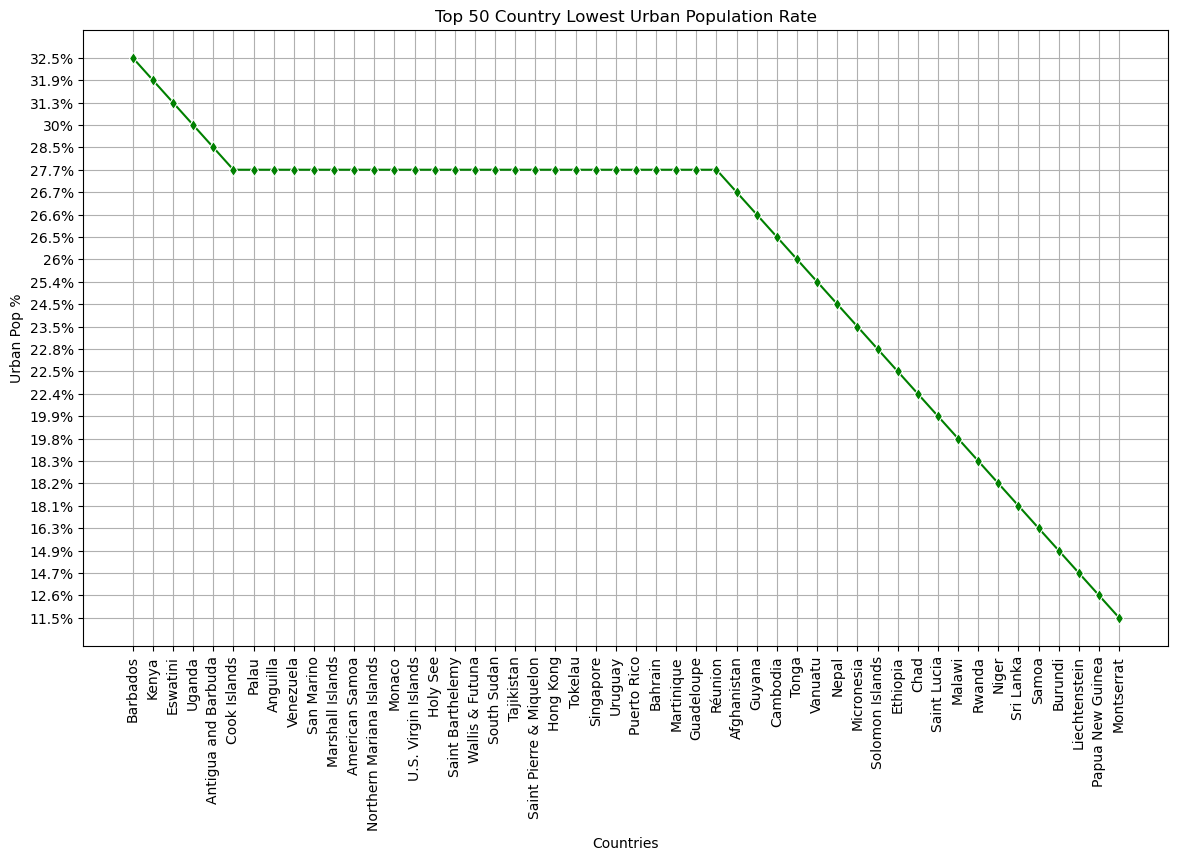

In [25]:
plt.figure(figsize = (14,8))
sns.lineplot(
    data =  low_urban,
    x = 'Country (or dependency)',
    y = 'Urban Pop %',
    color = 'Green',
    marker = 'd'
)
plt.xticks(rotation = 90)
plt.xlabel('Countries')
plt.grid()
plt.title('Top 50 Country Lowest Urban Population Rate')
plt.show()

* #### These Visualization is Used to Top 50 Least Urban Populated Countries According to This Data.
* #### Montserrat is the Highest Urban Populated Country in the World.
* #### Papua New Guinea is Second.
* #### In this list we can see lot of Countries where Least Populated Countries or Count of Population Comparitively Low Countires (Most Of Them).

### This dataset brings together the latest population statistics for 233 countries and territories, It reveals how countries are growing, shrinking, and evolving demographically.

### From population density to fertility rate, from migration trends to urbanization.This dataset includes key metrics like yearly population change, net migration, land area, fertility rate, and each country’s share of the world population.
